# Dataset507-trained SmallENet: 6x6 grid + 5x5 overlay reconstruction

`nnUNetTrainerSmallENet` trained on `Dataset507_ARCADE_refinement`
(channel 0 only -- `SMALLENET_INPUT_CHANNELS=0`, ignores the predicted-mask
channel; this is the single-channel baseline, not `SmallRefinementENet`)
has no grid-tiled test split of its own -- Dataset507's patches are placed
by discontinuity-detection/skeleton-FPS/random sampling, not a uniform
6x6/5x5 grid, so there's nothing to reconstruct *from within* Dataset507
itself (see `preview_smallenet_results.ipynb`'s multi-scale section, which
depends entirely on that grid layout and can't run against Dataset507 for
exactly this reason).

This notebook answers a different, apples-to-apples question instead: **if
you take the Dataset507-trained checkpoint's *weights* and run them through
the same standardized evaluation everything else in this repo uses**
(Dataset502_ARCADE_6x6_1c's own 6x6+5x5 grid patches, confidence-blend
reconstruction), how does its full-image dice compare to `SmallENet`
trained directly on 502/504/505? Same reconstruction code as
`preview_smallenet_results.ipynb` (`layer1_boxes`/`layer2_boxes`,
`confidence_weight_map`, `blend_source`), same evaluation source
(Dataset502's imagesTs/labelsTs), only the checkpoint differs -- so the
resulting numbers are directly comparable to the
`*_multiscale_summary_metrics.csv` files already saved for 502/504/505,
loaded and compared side-by-side at the end.

In [1]:
from __future__ import annotations

import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import matplotlib.patches as mpatches
import torch
from PIL import Image

# Same numpy/torch checkpoint-loading fix used in every other preview
# notebook this session -- checkpoints trained under numpy>=2.0 fail to
# load under numpy 1.26.4's torch.load(..., weights_only=False).
import numpy.core.multiarray as _ma

_orig_scalar = _ma.scalar


def _patched_scalar(dtype, obj):
    if not isinstance(dtype, np.dtype):
        try:
            dtype = np.dtype(dtype.type) if hasattr(dtype, "type") else np.dtype(dtype)
        except Exception as e:
            raise TypeError(f"could not coerce {dtype!r} to np.dtype") from e
    return _orig_scalar(dtype, obj)


_ma.scalar = _patched_scalar


def _find_repo_root(start: Path) -> Path:
    for candidate in [start, *start.parents]:
        if (candidate / "lightm-unet").exists() and (candidate / "data").exists():
            return candidate
    return start


REPO_ROOT = _find_repo_root(Path.cwd())
PACKAGE_ROOT = REPO_ROOT / "lightm-unet"
sys.path.insert(0, str(PACKAGE_ROOT))
from nnunetv2.nets.SmallENet import SmallENet  # noqa: E402

# Checkpoint: SmallENet trained ON Dataset507 (channel-0-only baseline).
CHECKPOINT_DATASET_NAME = "Dataset507_ARCADE_refinement"
TRAINER_NAME = "nnUNetTrainerSmallENet"
PLANS_NAME = "nnUNetPlans"
CONFIGURATION = "2d"
FOLD = 0
CHECKPOINT_NAME = "checkpoint_best.pth"

# Evaluation source: Dataset502's own 6x6+5x5 grid patches -- the
# standardized, non-vessel-biased evaluation surface used across this
# repo's experiments (Dataset505's own docs explicitly point evaluation
# back at 502 for the same reason). NOT Dataset507's imagesTs -- that has
# no grid structure to reconstruct from.
GRID_DATASET_NAME = "Dataset502_ARCADE_6x6_1c"
GRID_COLS, GRID_ROWS = 6, 6

NNUNET_RESULTS = REPO_ROOT / "data" / "nnUNET_results"
CHECKPOINT_PATH = (
    NNUNET_RESULTS / CHECKPOINT_DATASET_NAME / f"{TRAINER_NAME}__{PLANS_NAME}__{CONFIGURATION}"
    / f"fold_{FOLD}" / CHECKPOINT_NAME
)

GRID_DATASET_DIR = REPO_ROOT / "data" / "nnUNet_raw" / GRID_DATASET_NAME
IMAGES_TS_DIR = GRID_DATASET_DIR / "imagesTs"
LABELS_TS_DIR = GRID_DATASET_DIR / "labelsTs"

METRICS_DIR = REPO_ROOT / "analysis" / CHECKPOINT_DATASET_NAME / "results"
METRICS_DIR.mkdir(parents=True, exist_ok=True)
RESULT_TAG = f"{TRAINER_NAME}_on_{CHECKPOINT_DATASET_NAME}_via_{GRID_DATASET_NAME}grid"

# Must match nnUNetTrainerSmallENet.py defaults used at training time (train_small_enet_507.job left these default).
INITIAL_CHANNELS = 16
STAGE_CHANNELS = 32
LCN_KERNEL_SIZE = 9
THRESHOLD = 0.5

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("Repo root      :", REPO_ROOT)
print("Checkpoint     :", CHECKPOINT_PATH, CHECKPOINT_PATH.exists())
print("Grid imagesTs  :", IMAGES_TS_DIR, len(list(IMAGES_TS_DIR.glob("*.png"))) if IMAGES_TS_DIR.exists() else "MISSING")
print("Grid labelsTs  :", LABELS_TS_DIR, len(list(LABELS_TS_DIR.glob("*.png"))) if LABELS_TS_DIR.exists() else "MISSING")
print("Device         :", DEVICE)

Repo root      : /workspace/LightM-UNet
Checkpoint     : /workspace/LightM-UNet/data/nnUNET_results/Dataset507_ARCADE_refinement/nnUNetTrainerSmallENet__nnUNetPlans__2d/fold_0/checkpoint_best.pth True


Grid imagesTs  : /workspace/LightM-UNet/data/nnUNet_raw/Dataset502_ARCADE_6x6_1c/imagesTs 18300


Grid labelsTs  : /workspace/LightM-UNet/data/nnUNet_raw/Dataset502_ARCADE_6x6_1c/labelsTs 18300
Device         : cuda


## Load the Dataset507-trained checkpoint

In [2]:
model = SmallENet(
    in_channels=1,
    out_channels=1,
    initial_channels=INITIAL_CHANNELS,
    stage_channels=STAGE_CHANNELS,
    lcn_kernel_size=LCN_KERNEL_SIZE,
)

checkpoint = torch.load(CHECKPOINT_PATH, map_location=DEVICE, weights_only=False)
model.load_state_dict(checkpoint["network_weights"])
model = model.to(DEVICE).eval()

print(f"Loaded {CHECKPOINT_NAME} (trained on {CHECKPOINT_DATASET_NAME}) from epoch {checkpoint.get('current_epoch')}")
n_params = sum(p.numel() for p in model.parameters())
print(f"Parameters: {n_params:,}")

Loaded checkpoint_best.pth (trained on Dataset507_ARCADE_refinement) from epoch 149
Parameters: 8,297


## Build the Dataset502 grid-patch sample index and inference helpers

In [3]:
IMG_EXTS = {".png", ".jpg", ".jpeg", ".bmp", ".tif", ".tiff"}


def case_id_from_image(path: Path) -> str:
    stem = path.stem
    return stem[:-5] if stem.endswith("_0000") else stem


def image_files(folder: Path) -> list[Path]:
    return sorted(p for p in folder.iterdir() if p.suffix.lower() in IMG_EXTS)


img_files = image_files(IMAGES_TS_DIR)
gt_files = {p.stem: p for p in image_files(LABELS_TS_DIR)}

samples = []
for img in img_files:
    cid = case_id_from_image(img)
    if cid in gt_files:
        samples.append({"case_id": cid, "image": img, "gt": gt_files[cid]})

print(f"ImagesTs found  : {len(img_files)}")
print(f"LabelsTs found  : {len(gt_files)}")
print(f"Matched samples : {len(samples)}")
if not samples:
    raise FileNotFoundError(f"No matched samples found under {GRID_DATASET_DIR}")

case_by_id = {s["case_id"]: s for s in samples}
case_id_to_idx = {s["case_id"]: i for i, s in enumerate(samples)}


def load_gray(path: Path) -> np.ndarray:
    return np.asarray(Image.open(path).convert("L"), dtype=np.float32)


def load_gt(path: Path) -> np.ndarray:
    arr = np.asarray(Image.open(path))
    if arr.ndim == 3:
        arr = arr[..., 0]
    return arr


def zscore_normalize(image: np.ndarray) -> np.ndarray:
    """Matches nnunetv2.preprocessing.normalization.ZScoreNormalization with
    use_mask_for_norm=False (whole-image mean/std) -- same convention the
    Dataset507-trained checkpoint saw at training time."""
    mean = image.mean()
    std = image.std()
    return (image - mean) / max(std, 1e-8)


@torch.no_grad()
def predict_case(idx: int) -> tuple[np.ndarray, np.ndarray, np.ndarray]:
    """Returns (raw grayscale, GT binary mask, predicted probability map)."""
    item = samples[idx]
    raw = load_gray(item["image"])
    gt = (load_gt(item["gt"]) > 0)

    normed = zscore_normalize(raw)
    x = torch.from_numpy(normed).float()[None, None].to(DEVICE)  # 1,1,H,W
    logits = model(x)
    prob = torch.sigmoid(logits)[0, 0].cpu().numpy()
    return raw, gt, prob


_patch_cache: dict[str, tuple[np.ndarray, np.ndarray, np.ndarray]] = {}


def predict_cached(case_id: str):
    if case_id not in _patch_cache:
        _patch_cache[case_id] = predict_case(case_id_to_idx[case_id])
    return _patch_cache[case_id]

ImagesTs found  : 18300
LabelsTs found  : 18300
Matched samples : 18300


## Group patches by source frame + grid position, and the confidence-blend machinery

Identical to `preview_smallenet_results.ipynb`'s multi-scale reconstruction
section (`layer1_boxes`/`layer2_boxes`, `confidence_weight_map`,
`load_source_patches`, `blend_source`, `dice_for_views`) -- reused as-is,
just running through this notebook's own `predict_cached` (backed by the
Dataset507-trained checkpoint) instead.

In [4]:
import re

sys.path.insert(0, str(REPO_ROOT / "dataset-prep"))
from patch_grid import layer1_boxes, layer2_boxes  # noqa: E402

FNAME_RE = re.compile(r"^(?P<stem>.+)_(?P<kind>[pb])(?P<row>\d{2})(?P<col>\d{2})$")


def parse_case_id(case_id: str):
    m = FNAME_RE.match(case_id)
    if not m:
        return None
    return m.group("stem"), m.group("kind"), int(m.group("row")), int(m.group("col"))


stems: dict[str, dict[str, dict[tuple[int, int], str]]] = {}
for s in samples:
    parsed = parse_case_id(s["case_id"])
    if parsed is None:
        continue
    stem, kind, row, col = parsed
    stems.setdefault(stem, {"p": {}, "b": {}})[kind][(row, col)] = s["case_id"]

complete_stems = sorted(
    stem for stem, entry in stems.items()
    if len(entry["p"]) == GRID_ROWS * GRID_COLS and len(entry["b"]) == (GRID_ROWS - 1) * (GRID_COLS - 1)
)
print(f"Source images found         : {len(stems)}")
print(f"With full 6x6 + 5x5 patches : {len(complete_stems)}")


def confidence_weight_map(
    shape: tuple[int, int],
    center_frac: float = 0.2,
    min_confidence: float = 0.5,
    max_confidence: float = 1.0,
    falloff: str = "linear",
    metric: str = "chebyshev",
) -> np.ndarray:
    h, w = shape
    yy, xx = np.mgrid[0:h, 0:w].astype(np.float64)
    cy, cx = (h - 1) / 2.0, (w - 1) / 2.0
    dy, dx = np.abs(yy - cy), np.abs(xx - cx)

    if metric == "chebyshev":
        dist = np.maximum(dy, dx)
        max_dist = max(cy, cx, 1e-8)
    elif metric == "euclidean":
        dist = np.sqrt(dy ** 2 + dx ** 2)
        max_dist = np.sqrt(cy ** 2 + cx ** 2) + 1e-8
    else:
        raise ValueError(f"Unknown metric: {metric!r}")
    d = np.clip(dist / max_dist, 0.0, 1.0)

    d0 = np.sqrt(np.clip(center_frac, 0.0, 1.0))
    t = np.clip((d - d0) / max(1.0 - d0, 1e-8), 0.0, 1.0)
    if falloff == "linear":
        curve = t
    elif falloff == "gaussian":
        curve = 1.0 - np.exp(-3.0 * t ** 2)
        curve /= (1.0 - np.exp(-3.0))
    else:
        raise ValueError(f"Unknown falloff: {falloff!r}")

    weight = max_confidence - curve * (max_confidence - min_confidence)
    return weight.astype(np.float32)


RING_KWARGS = dict(center_frac=0.2, min_confidence=0.5, max_confidence=1.0, falloff="linear", metric="chebyshev")


def load_source_patches(stem: str) -> dict:
    entry = stems[stem]
    p_ids, b_ids = entry["p"], entry["b"]
    if len(p_ids) != GRID_ROWS * GRID_COLS:
        raise ValueError(f"{stem}: expected {GRID_ROWS * GRID_COLS} p-patches, got {len(p_ids)}")

    row0_widths = [load_gray(case_by_id[p_ids[(0, c)]]["image"]).shape[1] for c in range(GRID_COLS)]
    col0_heights = [load_gray(case_by_id[p_ids[(r, 0)]]["image"]).shape[0] for r in range(GRID_ROWS)]
    width, height = sum(row0_widths), sum(col0_heights)

    boxes1 = layer1_boxes(width, height, GRID_COLS, GRID_ROWS)
    boxes2 = layer2_boxes(width, height, GRID_COLS, GRID_ROWS)

    raw_canvas = np.zeros((height, width), dtype=np.float32)
    gt_canvas = np.zeros((height, width), dtype=bool)
    prob1_canvas = np.zeros((height, width), dtype=np.float32)
    prob2_canvas = np.zeros((height, width), dtype=np.float32)
    prob2_covered = np.zeros((height, width), dtype=bool)
    p_patches, b_patches = [], []

    for r in range(GRID_ROWS):
        for c in range(GRID_COLS):
            box = boxes1[r][c]
            x0, y0, x1, y1 = box
            raw, gt, prob = predict_cached(p_ids[(r, c)])
            raw_canvas[y0:y1, x0:x1] = raw
            gt_canvas[y0:y1, x0:x1] = gt
            prob1_canvas[y0:y1, x0:x1] = prob
            p_patches.append((box, prob))

    for r in range(GRID_ROWS - 1):
        for c in range(GRID_COLS - 1):
            case_id = b_ids.get((r, c))
            if case_id is None:
                continue
            box = boxes2[r][c]
            x0, y0, x1, y1 = box
            _, _, prob = predict_cached(case_id)
            prob2_canvas[y0:y1, x0:x1] = prob
            prob2_covered[y0:y1, x0:x1] = True
            b_patches.append((box, prob))

    return {
        "stem": stem, "width": width, "height": height,
        "raw": raw_canvas, "gt": gt_canvas,
        "prob_6x6": prob1_canvas, "prob_5x5": prob2_canvas, "prob_5x5_covered": prob2_covered,
        "p_patches": p_patches, "b_patches": b_patches,
    }


def blend_source(loaded: dict, ring_kwargs: dict | None = None) -> dict:
    ring_kwargs = ring_kwargs or {}
    height, width = loaded["height"], loaded["width"]
    weighted_sum = np.zeros((height, width), dtype=np.float32)
    weight_sum = np.zeros((height, width), dtype=np.float32)

    for box, prob in loaded["p_patches"] + loaded["b_patches"]:
        x0, y0, x1, y1 = box
        w = confidence_weight_map(prob.shape, **ring_kwargs)
        weighted_sum[y0:y1, x0:x1] += prob * w
        weight_sum[y0:y1, x0:x1] += w

    blended_prob = weighted_sum / np.maximum(weight_sum, 1e-8)
    pred_6x6 = loaded["prob_6x6"] > THRESHOLD
    pred_5x5 = loaded["prob_5x5"] > THRESHOLD
    return {
        "pred_6x6": pred_6x6,
        "pred_5x5": pred_5x5,
        "pred_or": pred_6x6 | pred_5x5,
        "blended_prob": blended_prob,
        "pred_blend": blended_prob > THRESHOLD,
    }


EPS = 1e-8


def prf_from_counts(tp: int, fp: int, fn: int, tn: int) -> dict[str, float]:
    precision = tp / (tp + fp + EPS)
    recall = tp / (tp + fn + EPS)
    dice = (2 * tp) / (2 * tp + fp + fn + EPS)
    accuracy = (tp + tn) / (tp + fp + fn + tn + EPS)
    return {"dice_f1": dice, "precision": precision, "recall_sensitivity": recall, "accuracy": accuracy}


def dice_for_views(gt: np.ndarray, blend: dict) -> pd.DataFrame:
    views = {
        "6x6 only": blend["pred_6x6"],
        "5x5 only": blend["pred_5x5"],
        "OR (6x6 | 5x5)": blend["pred_or"],
        "confidence blend": blend["pred_blend"],
    }
    rows = []
    for name, pred in views.items():
        tp = int((gt & pred).sum()); fp = int((~gt & pred).sum())
        fn = int((gt & ~pred).sum()); tn = int((~gt & ~pred).sum())
        rows.append({"view": name, **prf_from_counts(tp, fp, fn, tn)})
    return pd.DataFrame(rows)

Source images found         : 300
With full 6x6 + 5x5 patches : 300


## Preview a few reconstructed source images

Saved: /workspace/LightM-UNet/analysis/Dataset507_ARCADE_refinement/results/nnUNetTrainerSmallENet_on_Dataset507_ARCADE_refinement_via_Dataset502_ARCADE_6x6_1cgrid_test_1_reconstruction.png


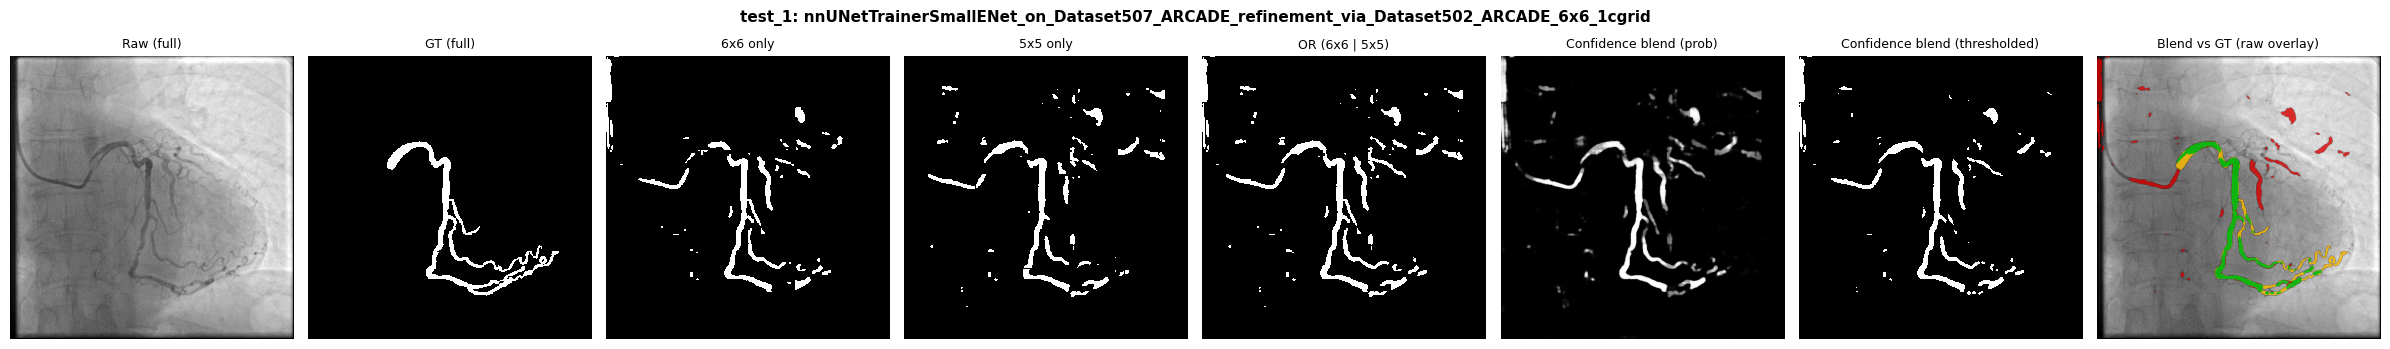

Per-view dice for test_1:


,view,dice_f1,precision,recall_sensitivity,accuracy
0,6x6 only,0.568137,0.524971,0.619037,0.968544
1,5x5 only,0.554158,0.510630,0.605798,0.967419
2,OR (6x6 | 5x5),0.550806,0.446908,0.717644,0.960876
3,confidence blend,0.578686,0.524849,0.644830,0.968616


Saved: /workspace/LightM-UNet/analysis/Dataset507_ARCADE_refinement/results/nnUNetTrainerSmallENet_on_Dataset507_ARCADE_refinement_via_Dataset502_ARCADE_6x6_1cgrid_test_10_reconstruction.png


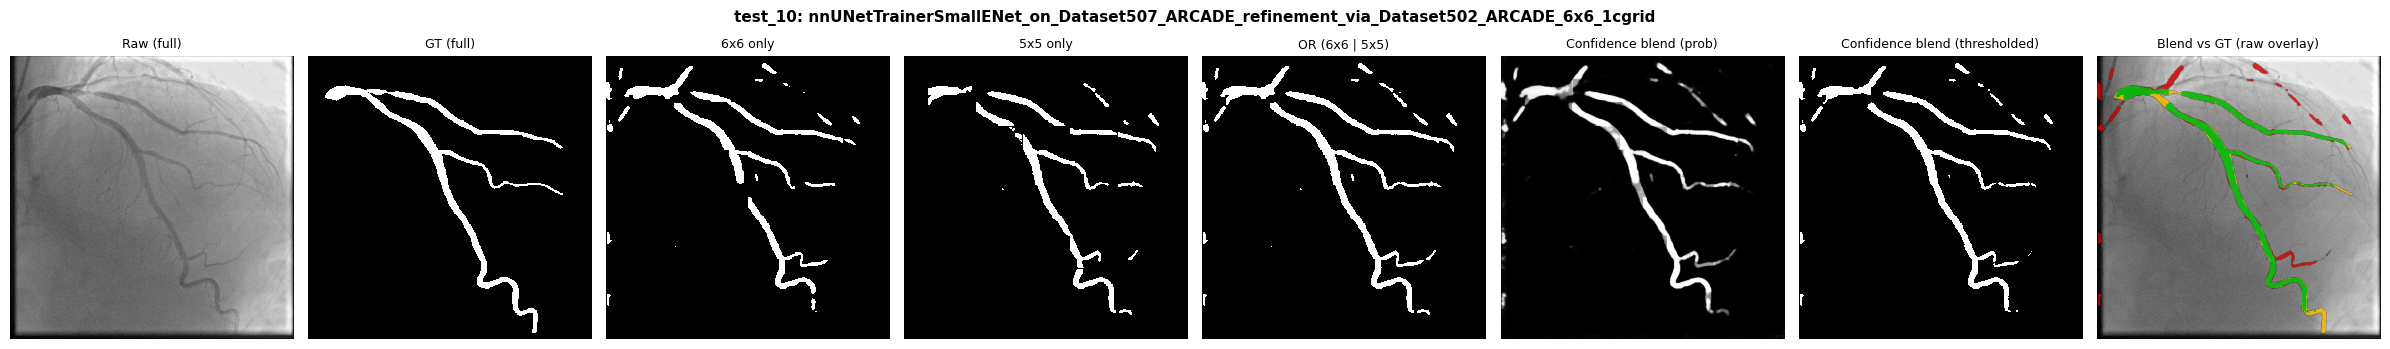

Per-view dice for test_10:


,view,dice_f1,precision,recall_sensitivity,accuracy
0,6x6 only,0.767008,0.741432,0.794412,0.975883
1,5x5 only,0.813473,0.838315,0.790060,0.981895
2,OR (6x6 | 5x5),0.793373,0.719171,0.884648,0.976974
3,confidence blend,0.790851,0.746543,0.840751,0.977779


Saved: /workspace/LightM-UNet/analysis/Dataset507_ARCADE_refinement/results/nnUNetTrainerSmallENet_on_Dataset507_ARCADE_refinement_via_Dataset502_ARCADE_6x6_1cgrid_test_100_reconstruction.png


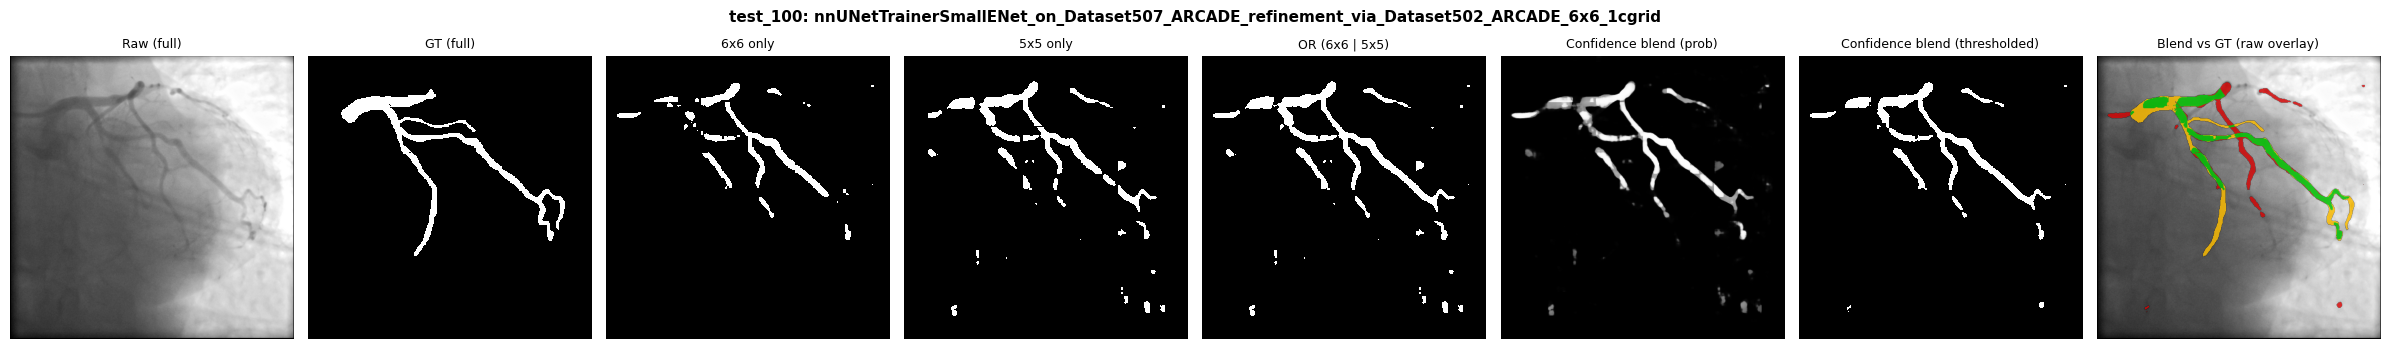

Per-view dice for test_100:


,view,dice_f1,precision,recall_sensitivity,accuracy
0,6x6 only,0.501797,0.621384,0.420810,0.961922
1,5x5 only,0.600726,0.613218,0.588733,0.964336
2,OR (6x6 | 5x5),0.614017,0.593333,0.636196,0.963551
3,confidence blend,0.615870,0.656650,0.579859,0.967037


In [5]:
CLASS_COLORS = ["#000000", "#ffffff"]
CMAP = mcolors.ListedColormap(CLASS_COLORS)
NORM = mcolors.BoundaryNorm([0, 1, 2], 2)
IMSHOW_MASK_KW = dict(cmap=CMAP, norm=NORM, interpolation="nearest")

CONFUSION_COLORS = {
    "TP": np.array([0, 200, 0, 210], dtype=np.uint8),
    "FP": np.array([220, 0, 0, 200], dtype=np.uint8),
    "FN": np.array([255, 190, 0, 210], dtype=np.uint8),
}


def make_confusion(gt: np.ndarray, pred: np.ndarray) -> np.ndarray:
    overlay = np.zeros((*gt.shape, 4), dtype=np.uint8)
    overlay[gt & pred] = CONFUSION_COLORS["TP"]
    overlay[~gt & pred] = CONFUSION_COLORS["FP"]
    overlay[gt & ~pred] = CONFUSION_COLORS["FN"]
    return overlay


def show_reconstruction(stem: str, ring_kwargs: dict | None = None, save_path: Path | None = None):
    loaded = load_source_patches(stem)
    blend = blend_source(loaded, ring_kwargs)
    gt = loaded["gt"]
    confusion_blend = make_confusion(gt, blend["pred_blend"])

    panels = [
        ("Raw (full)", loaded["raw"], dict(cmap="gray")),
        ("GT (full)", gt, IMSHOW_MASK_KW),
        ("6x6 only", blend["pred_6x6"], IMSHOW_MASK_KW),
        ("5x5 only", blend["pred_5x5"], IMSHOW_MASK_KW),
        ("OR (6x6 | 5x5)", blend["pred_or"], IMSHOW_MASK_KW),
        ("Confidence blend (prob)", blend["blended_prob"], dict(cmap="gray", vmin=0, vmax=1)),
        ("Confidence blend (thresholded)", blend["pred_blend"], IMSHOW_MASK_KW),
    ]
    fig, axes = plt.subplots(1, len(panels) + 1, figsize=(3.0 * (len(panels) + 1), 3.6))
    for ax, (title, arr, kw) in zip(axes, panels):
        ax.imshow(arr, **kw)
        ax.set_title(title, fontsize=9)
        ax.axis("off")
    axes[-1].imshow(loaded["raw"], cmap="gray")
    axes[-1].imshow(confusion_blend)
    axes[-1].set_title("Blend vs GT (raw overlay)", fontsize=9)
    axes[-1].axis("off")
    fig.suptitle(f"{stem}: {RESULT_TAG}", fontsize=11, fontweight="bold")
    plt.tight_layout()
    if save_path:
        fig.savefig(save_path, bbox_inches="tight", dpi=150)
        print(f"Saved: {save_path}")
    plt.show()

    dice_table = dice_for_views(gt, blend)
    print(f"Per-view dice for {stem}:")
    display(dice_table)
    return loaded, blend, dice_table


demo_stems = complete_stems[:3]
for _stem in demo_stems:
    show_reconstruction(_stem, RING_KWARGS, save_path=METRICS_DIR / f"{RESULT_TAG}_{_stem}_reconstruction.png")

## Dice on all views, aggregated over every reconstructed test image

In [6]:
_agg_rows = []
for _stem in complete_stems:
    _loaded = load_source_patches(_stem)
    _blend = blend_source(_loaded, RING_KWARGS)
    _dice_table = dice_for_views(_loaded["gt"], _blend)
    _dice_table.insert(0, "stem", _stem)
    _agg_rows.append(_dice_table)

multiscale_metrics = pd.concat(_agg_rows, ignore_index=True)
multiscale_summary = (
    multiscale_metrics.groupby("view")[["dice_f1", "precision", "recall_sensitivity", "accuracy"]]
    .mean()
    .reset_index()
    .sort_values("dice_f1", ascending=False, ignore_index=True)
)

print(f"Multi-scale reconstruction dice ({RESULT_TAG}), averaged over {len(complete_stems)} full test images:")
display(multiscale_summary)

multiscale_metrics.to_csv(METRICS_DIR / f"{RESULT_TAG}_multiscale_per_image_metrics.csv", index=False)
multiscale_summary.to_csv(METRICS_DIR / f"{RESULT_TAG}_multiscale_summary_metrics.csv", index=False)
print("Saved multi-scale metrics to", METRICS_DIR)

Multi-scale reconstruction dice (nnUNetTrainerSmallENet_on_Dataset507_ARCADE_refinement_via_Dataset502_ARCADE_6x6_1cgrid), averaged over 300 full test images:


,view,dice_f1,precision,recall_sensitivity,accuracy
0,confidence blend,0.587250,0.521062,0.701982,0.966426
1,6x6 only,0.564657,0.521310,0.642707,0.966199
2,5x5 only,0.563983,0.519453,0.646341,0.966464
3,OR (6x6 | 5x5),0.560974,0.460303,0.753945,0.959950


Saved multi-scale metrics to /workspace/LightM-UNet/analysis/Dataset507_ARCADE_refinement/results


## Compare against previous results (SmallENet trained on 502 / 504 / 505)

Loads the `*_multiscale_summary_metrics.csv` files already saved by
`preview_smallenet_results.ipynb` for the models trained directly on the
grid datasets, adds this notebook's Dataset507-trained result, and compares
all four side by side on the same "confidence blend" view (the best view in
every prior run) plus a full per-view breakdown table.

Full per-view comparison:


,model,view,dice_f1,precision,recall_sensitivity,accuracy
0,SmallENet trained on 502,5x5 only,0.553931,0.561776,0.572235,0.970609
1,SmallENet trained on 504,5x5 only,0.563343,0.572227,0.579438,0.970145
2,SmallENet trained on 505,5x5 only,0.515446,0.424247,0.698100,0.955902
3,SmallENet trained on 507 (ch.0 baseline),5x5 only,0.563983,0.519453,0.646341,0.966464
4,SmallENet trained on 502,6x6 only,0.555177,0.581173,0.553780,0.971240
5,SmallENet trained on 504,6x6 only,0.551731,0.576296,0.554148,0.969531
6,SmallENet trained on 505,6x6 only,0.511288,0.419983,0.688240,0.955531
7,SmallENet trained on 507 (ch.0 baseline),6x6 only,0.564657,0.521310,0.642707,0.966199
8,SmallENet trained on 502,OR (6x6 | 5x5),0.568843,0.517258,0.662119,0.967885
9,SmallENet trained on 504,OR (6x6 | 5x5),0.567420,0.511505,0.666937,0.965729



Confidence-blend dice only (the best view in every prior run) -- the headline comparison:


,model,dice_f1,precision,recall_sensitivity,accuracy
0,SmallENet trained on 507 (ch.0 baseline),0.587250,0.521062,0.701982,0.966426
1,SmallENet trained on 502,0.583142,0.599889,0.590855,0.972809
2,SmallENet trained on 504,0.578860,0.594936,0.589544,0.971017
3,SmallENet trained on 505,0.527681,0.419310,0.750712,0.954684


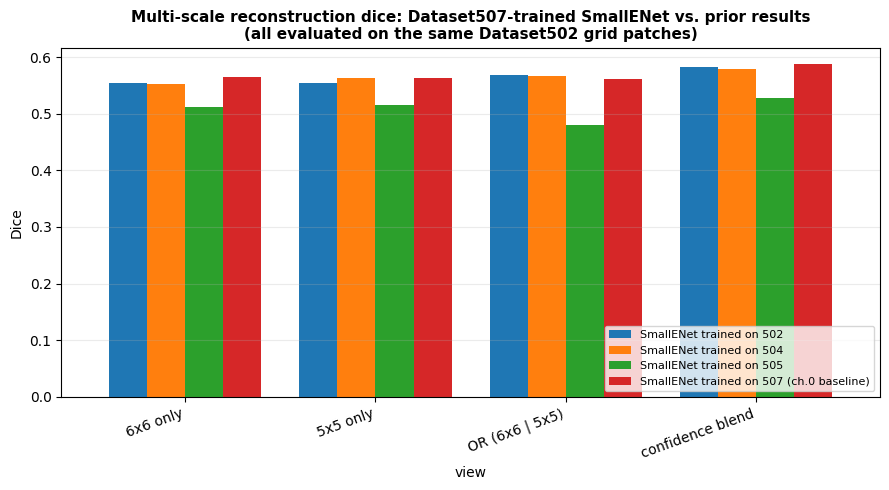

In [7]:
PRIOR_RESULTS = {
    "SmallENet trained on 502": REPO_ROOT / "analysis" / "502_ARCADE_6x6_1c" / "results" / "nnUNetTrainerSmallENet_multiscale_summary_metrics.csv",
    "SmallENet trained on 504": REPO_ROOT / "analysis" / "Dataset504_ARCADE_6x6_1c_noempty" / "results" / "nnUNetTrainerSmallENet_multiscale_summary_metrics.csv",
    "SmallENet trained on 505": REPO_ROOT / "analysis" / "Dataset505_ARCADE_oversampled" / "results" / "nnUNetTrainerSmallENet_multiscale_summary_metrics.csv",
}
THIS_LABEL = "SmallENet trained on 507 (ch.0 baseline)"

comparison_rows = []
for label, path in PRIOR_RESULTS.items():
    if not path.exists():
        print(f"WARNING: missing {path}, skipping {label}")
        continue
    df = pd.read_csv(path)
    df.insert(0, "model", label)
    comparison_rows.append(df)

this_result = multiscale_summary.copy()
this_result.insert(0, "model", THIS_LABEL)
comparison_rows.append(this_result)

comparison_df = pd.concat(comparison_rows, ignore_index=True)
comparison_df.to_csv(METRICS_DIR / f"{RESULT_TAG}_vs_prior_multiscale_comparison.csv", index=False)

print("Full per-view comparison:")
display(comparison_df.sort_values(["view", "model"]).reset_index(drop=True))

print("\nConfidence-blend dice only (the best view in every prior run) -- the headline comparison:")
blend_only = (
    comparison_df[comparison_df["view"] == "confidence blend"]
    [["model", "dice_f1", "precision", "recall_sensitivity", "accuracy"]]
    .sort_values("dice_f1", ascending=False, ignore_index=True)
)
display(blend_only)

fig, ax = plt.subplots(figsize=(9, 5))
pivot = comparison_df.pivot(index="view", columns="model", values="dice_f1")
pivot = pivot.reindex(["6x6 only", "5x5 only", "OR (6x6 | 5x5)", "confidence blend"])
pivot.plot(kind="bar", ax=ax, width=0.8)
ax.set_ylabel("Dice")
ax.set_title("Multi-scale reconstruction dice: Dataset507-trained SmallENet vs. prior results\n"
              "(all evaluated on the same Dataset502 grid patches)", fontsize=11, fontweight="bold")
ax.legend(fontsize=8, loc="lower right")
ax.grid(axis="y", alpha=0.25)
plt.xticks(rotation=20, ha="right")
plt.tight_layout()
fig.savefig(METRICS_DIR / f"{RESULT_TAG}_vs_prior_comparison.png", dpi=150, bbox_inches="tight")
plt.show()